# Dynamic Model Verification

This notebook verifies the extended multi-nutrient competitive catabolism model with hormonal regulation and nitrogen dynamics.

In [1]:
from multi_nutrient_model_glucagon import (
    ref_parameters, initial_state, equation, fluxes,
    perturbation_dynamics, insulin_clamp_dynamic,
    vATP, steady_state, I0, GCG0, PARAMETER_NAMES as PARAMETER_NAMES_EXT
)
from scipy.integrate import odeint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set font size and style to match type_I_diabetes.ipynb
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

## 1. Verify Steady State

Check that the reference parameters and initial state satisfy steady-state conditions (all derivatives = 0).

In [2]:
# Get reference parameters and initial state
p_ref = ref_parameters()
x0 = initial_state()


## 2. Type I Diabetes Simulation

Test the model's response to insulin deficiency (Type I diabetes simulation).

In [3]:
# =============================================================================
# Extended model (with glucagon) simulation
# =============================================================================

# Simulate Type I diabetes: sudden loss of insulin secretion
# First 30 minutes at baseline, then remove insulin secretion

# Get reference parameters
p_ext = ref_parameters()

# Baseline period
time_1 = np.linspace(0, 30, 100)
X_1, F_1 = perturbation_dynamics(time_1, 1.0, p=p_ext)

# Remove insulin secretion (I_max = 0)
time_2 = np.linspace(30, 150, 100)
x0_phase2 = X_1.iloc[-1][['L', 'G', 'F', 'K', 'I', 'IA', 'GCG', 'GCGA']].values
X_2, F_2 = perturbation_dynamics(time_2, 1.0, X0=x0_phase2, p=p_ext, I_max=0.0)

# Concatenate results
X_diabetes_ext = pd.concat([X_1, X_2], axis=0, ignore_index=True)
F_diabetes_ext = pd.concat([F_1, F_2], axis=0, ignore_index=True)

# Rescale the data to physiological units
# Core metabolites:
X_diabetes_ext['G'] = X_diabetes_ext['G'] * 7.0  # mM (glucose)
X_diabetes_ext['F'] = X_diabetes_ext['F'] * 0.5  # mM (fatty acids)
X_diabetes_ext['K'] = X_diabetes_ext['K'] * 0.5  # mM (ketones/3HB)
X_diabetes_ext['L'] = X_diabetes_ext['L'] * 0.7  # mM (lactate)

# Scale hormones to relative units (fold change from baseline)
X_diabetes_ext['I'] = X_diabetes_ext['I'] / I0
X_diabetes_ext['GCG'] = X_diabetes_ext['GCG'] / GCG0



In [4]:
# =============================================================================
# Base model (without amino acids) simulation
# =============================================================================

# Import base model
import sys
sys.path.insert(0, '../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    perturbation_dynamics as perturbation_dynamics_base,
    PARAMETER_NAMES
)

# Setup base model parameters
K_i_ketogenesis = 0.2
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)

# Baseline period
time_1_base = np.linspace(0, 30, 100)
X_1_base = perturbation_dynamics_base(time_1_base, 1.0, p=p_base)[0]

# Remove insulin secretion
time_2_base = np.linspace(30, 150, 100)
Imax0 = p_base[PARAMETER_NAMES.index("I_max")]
X_2_base = perturbation_dynamics_base(time_2_base, 1.0, p=p_base, I_max=0*Imax0)[0]

# Concatenate results
X_diabetes_base = pd.concat([X_1_base, X_2_base], axis=0, ignore_index=True)

# Scale concentrations to physiological units
X_diabetes_base['G'] = X_diabetes_base['G'] * 7.0  # mM
X_diabetes_base['F'] = X_diabetes_base['F'] * 0.5  # mM
X_diabetes_base['K'] = X_diabetes_base['K'] * 0.5  # mM
X_diabetes_base['L'] = X_diabetes_base['L'] * 0.7  # mM



In [5]:
# Prepare data for plotting
plot_data_ext = X_diabetes_ext[['time', 'G', 'F', 'K']].melt(id_vars=['time'], var_name='variable', value_name='value')
plot_data_ext['model'] = 'Extended'

plot_data_base = X_diabetes_base[['time', 'G', 'F', 'K']].melt(id_vars=['time'], var_name='variable', value_name='value')
plot_data_base['model'] = 'Base'

# Combine data
plot_data_combined = pd.concat([plot_data_ext, plot_data_base], axis=0, ignore_index=True)

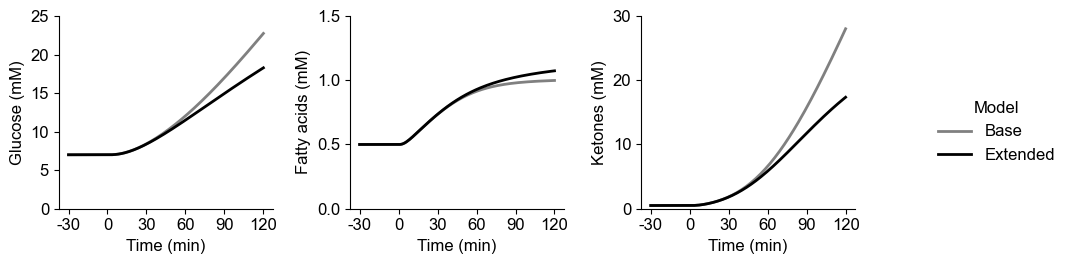

In [6]:
# Plot comparison: Extended model vs Base model
g = sns.FacetGrid(plot_data_combined, col="variable", col_wrap=3, height=2.8, aspect=0.9,
                  col_order=['G', 'F', 'K'], sharey=False, sharex=False, hue='model',
                  hue_order=['Base', 'Extended',],
                  palette={'Extended': 'black', 'Base': 'grey'})

g.map_dataframe(sns.lineplot, x="time", y="value", linewidth=2)

# Edit x ticks
for a in g.axes:
    a.set_xticks([0, 30, 60, 90, 120, 150], [-30, 0, 30, 60, 90, 120])

# Set y-axis limits (matching base model)
g.axes[0].set_ylim(0, 25)
g.axes[1].set_ylim(0, 1.5)
g.axes[2].set_ylim(0, 30.0)

# Change y and x labels with proper units
g.axes[0].set_ylabel("Glucose (mM)")
g.axes[1].set_ylabel("Fatty acids (mM)")
g.axes[2].set_ylabel("Ketones (mM)")

for i in range(3):
    g.axes[i].set_xlabel("Time (min)")

g.set_titles("")
g.add_legend(title='Model', bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.tight_layout()
sns.despine()
plt.savefig("./output/type_I_diabetes_comp.svg",format='svg', bbox_inches='tight')